In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Loading data...
RAVDESS data loaded.
CREMA-D data loaded.
TESS data loaded.
SAVEE data loaded.
Training model...
Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3145 - loss: 2.2070 - val_accuracy: 0.3309 - val_loss: 1.6985 - learning_rate: 0.0010
Epoch 2/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4714 - loss: 1.4272 - val_accuracy: 0.5261 - val_loss: 1.2402 - learning_rate: 0.0010
Epoch 3/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5111 - loss: 1.2914 - val_accuracy: 0.5467 - val_loss: 1.1587 - learning_rate: 0.0010
Epoch 4/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5359 - loss: 1.2019 - val_accuracy: 0.5586 - val_loss: 1.1313 - learning_rate: 0.0010
Epoch 5/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5583 - loss: 1.1320 - val_accuracy: 0.5631 - val_loss: 1.1258 - learning_rate: 0.0010
Epoch 6/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5772 - loss: 1.1001 - val_accuracy: 0.5787 - val

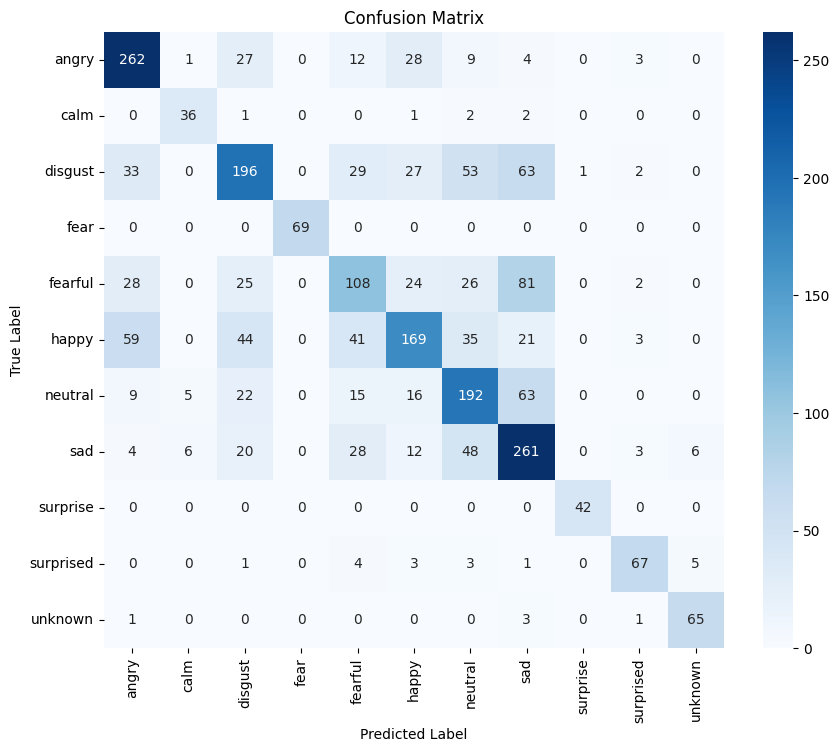

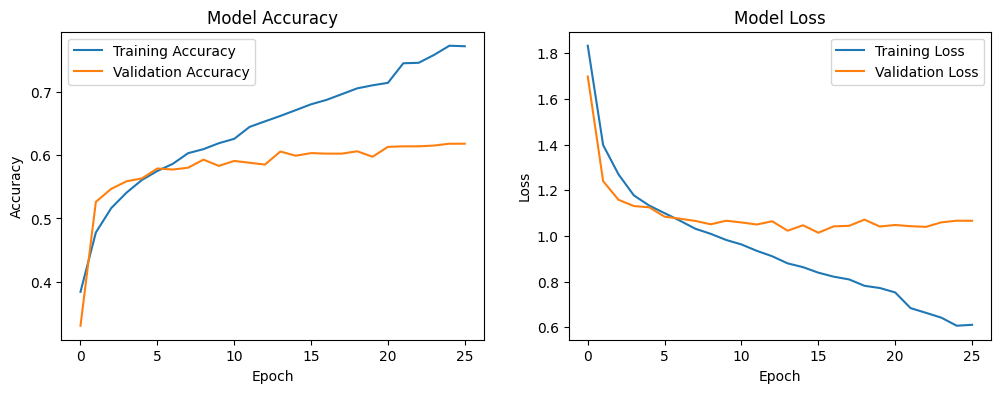

In [2]:
import numpy as np
import pandas as pd
import librosa
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Function to extract features from audio file
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, duration=3, offset=0.5, sr=None)
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfccs_processed = np.mean(mfccs.T, axis=0)
        return mfccs_processed
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

# Function to load data from a directory
def load_data_from_dir(dir_path, emotion):
    data = []
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.endswith('.wav'):
                file_path = os.path.join(root, file)
                features = extract_features(file_path)
                if features is not None:
                    data.append((features, emotion))
    return data

# Load data from all datasets
def load_all_data():
    data = []
    
    # RAVDESS
    ravdess = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"
    emotions = {'01':'neutral', '02':'calm', '03':'happy', '04':'sad', '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'}
    for actor in os.listdir(ravdess):
        for file in os.listdir(os.path.join(ravdess, actor)):
            emotion = emotions[file.split('-')[2]]
            file_path = os.path.join(ravdess, actor, file)
            features = extract_features(file_path)
            if features is not None:
                data.append((features, emotion))
    print("RAVDESS data loaded.")
    
    # CREMA-D
    Crema = "/kaggle/input/cremad/AudioWAV/"
    emotion_map = {'NEU':'neutral', 'HAP':'happy', 'SAD':'sad', 'ANG':'angry', 'FEA':'fearful', 'DIS':'disgust'}
    for file in os.listdir(Crema):
        parts = file.split('_')
        if len(parts) > 2:
            emotion = emotion_map.get(parts[2], 'unknown')
            file_path = os.path.join(Crema, file)
            features = extract_features(file_path)
            if features is not None:
                data.append((features, emotion))
    print("CREMA-D data loaded.")
    
    # TESS
    Tess = "/kaggle/input/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/"
    for emotion_dir in os.listdir(Tess):
        emotion = emotion_dir.split('_')[-1].lower()
        if emotion == 'ps':
            emotion = 'surprised'
        dir_path = os.path.join(Tess, emotion_dir)
        data.extend(load_data_from_dir(dir_path, emotion))
    print("TESS data loaded.")
    
    # SAVEE
    Savee = "/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/"
    emotion_map = {'a':'angry', 'd':'disgust', 'f':'fearful', 'h':'happy', 'n':'neutral', 'sa':'sad', 'su':'surprised'}
    for file in os.listdir(Savee):
        if file.endswith('.wav'):
            emotion = emotion_map.get(file.split('_')[1][0:2], 'unknown')
            file_path = os.path.join(Savee, file)
            features = extract_features(file_path)
            if features is not None:
                data.append((features, emotion))
    print("SAVEE data loaded.")
    
    return data

# Load and preprocess all data
print("Loading data...")
all_data = load_all_data()
X, y = zip(*all_data)
X = np.array(X)
y = np.array(y)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape input for CNN
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Define the model
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    
    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    
    Conv1D(256, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

# Train the model
print("Training model...")
history = model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_test_reshaped, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, lr_reduce]
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test)
print(f"Test accuracy: {test_accuracy*100:.2f}%")

# Make predictions
y_pred = model.predict(X_test_reshaped)
y_pred_classes = np.argmax(y_pred, axis=1)

# Print classification report
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the model
model.save('multi_dataset_speech_emotion_model.h5')



In [7]:
# Function to predict emotion for a new audio file
def predict_emotion(file_path):
    features = extract_features(file_path)
    if features is not None:
        features_scaled = scaler.transform(features.reshape(1, -1))
        features_reshaped = features_scaled.reshape(1, features_scaled.shape[1], 1)
        prediction = model.predict(features_reshaped)
        predicted_emotion = le.inverse_transform([np.argmax(prediction)])[0]
        return predicted_emotion
    else:
        return "Error processing file"

# Test the model on a new file
test_file = '/kaggle/input/cremad/AudioWAV/1001_IEO_FEA_HI.wav'
predicted_emotion = predict_emotion(test_file)
print(f"Predicted emotion for test file: {predicted_emotion}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted emotion for test file: fearful
